# Cellpose-SAM workbook
**Kernel:** `Cellpose-SAM Apple M1 (.venv)`.

Run setup once, list your files, choose an image, then edit/rerun the preview cell with **Ctrl+Enter**. The image and model remain in memory; rerun the image-loading cell only when choosing another image. This workbook segments 2D Z maximum projections.

In [1]:
from pathlib import Path
import sys
from time import perf_counter
from importlib.metadata import version

import numpy as np
import tifffile
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
from cellpose import models, plot

print(f"Cellpose {version('cellpose')} | PyTorch {torch.__version__}")
print(f"Kernel: {sys.executable}")
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())
if not torch.backends.mps.is_available():
    raise RuntimeError("MPS unavailable: select the Cellpose-SAM Apple M1 (.venv) kernel.")
device = torch.device("mps")

# Verify an actual GPU computation before loading the model.
x = torch.ones((256, 256), device=device)
y = x @ x
torch.mps.synchronize()
assert y.device.type == "mps" and y[0, 0].item() == 256.0, "GPU computation failed."
print(f"GPU computation passed ({y.device}).")
del x, y

/Users/jefflee/Documents/Tools/Image-analysis/Segmentation/Cellpose-SAM-AppleM1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cellpose 4.2.1.1 | PyTorch 2.14.0
Kernel: /Users/jefflee/Documents/Tools/Image-analysis/Segmentation/Cellpose-SAM-AppleM1/.venv/bin/python
MPS built: True
MPS available: True
GPU computation passed (mps:0).


## Setup · run once

Choose `MODEL_NAME` in the next cell, then rerun that cell and preview when switching models:

- `cpsam_v2`: updated SAM ViT-L model (default).
- `cpsam`: original SAM model.
- `cpdino`: DINOv3 ViT-L model.
- `cpdino-vitb`: smaller DINOv3 ViT-B model.

DINOv3 is installed in this environment. Restart an already-running kernel after installation. Each model downloads its weights on first use. See the [official model descriptions](https://cellpose.readthedocs.io/en/latest/models.html).

In [2]:
MODEL_NAME = "cpdino"  # cpsam_v2, cpsam, cpdino, or cpdino-vitb

def load_projection(path, axes):
    """Return all channels as float32 YXC, projecting only the explicit Z axis."""
    raw = tifffile.imread(path)
    axes = axes.upper()
    if axes not in {"YX", "CYX", "YXC", "ZYX", "ZCYX", "ZYXC"}:
        raise ValueError("Use YX, CYX, YXC, ZYX, ZCYX or ZYXC; split timepoints first.")
    if raw.ndim != len(axes):
        raise ValueError(f"Shape {raw.shape} does not match axes {axes!r}.")
    image = np.asarray(raw, dtype=np.float32)
    if "Z" in axes:
        image = image.max(axis=axes.index("Z"))
        axes = axes.replace("Z", "")
    image = np.moveaxis(image, axes.index("C"), -1) if "C" in axes else image[..., None]
    if not np.isfinite(image).all():
        raise ValueError("Image contains NaN or infinite values.")
    return np.ascontiguousarray(image)


assert MODEL_NAME in models.MODEL_NAMES, f"Choose from {models.MODEL_NAMES}"
# Cellpose may have been imported before DINOv3 was installed.
if MODEL_NAME.startswith("cpdino"):
    from dinov3.hub.backbones import dinov3_vitl16, dinov3_vitb16
    from cellpose import vit
    if not all(hasattr(vit, name) for name in ("dinov3_vitl16", "dinov3_vitb16")):
        raise RuntimeError("Stale Cellpose imports: restart the notebook kernel, then rerun setup.")

# Release the previous model before loading a different one on the GPU.
model = None
torch.mps.empty_cache()
model = models.CellposeModel(
    pretrained_model=MODEL_NAME, gpu=True, device=device, use_bfloat16=False
)

weights_device = next(model.net.parameters()).device
print("Model:", MODEL_NAME)
print("Cellpose device:", model.device)
print("Model weights:", weights_device)
assert model.device.type == "mps" and weights_device.type == "mps", "Cellpose is not on the GPU."
print("Cellpose is ready on the Apple GPU.")

Model: cpdino
Cellpose device: mps
Model weights: mps:0
Cellpose is ready on the Apple GPU.


## Choose a folder · list available files
Run this cell to see every filename and its zero-based index. Use that index in `TEST_INDEX` below.

In [3]:
INPUT_DIR = Path("/Volumes/Jeff-exFAT/Marko_HIV/080623/MARF1/Dox").expanduser()  # EDIT

files = sorted(p for p in INPUT_DIR.iterdir()
               if p.is_file() and p.suffix.lower() in {".tif", ".tiff"}
               and not p.stem.lower().endswith(("_label", "_masks")))
if not files:
    raise FileNotFoundError(f"No input TIFFs in {INPUT_DIR}")
for index, path in enumerate(files):
    print(f"{index:4d}  {path.name}")

   0  MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__01_Series_01.tif
   1  MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__02_Series_02.tif
   2  MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__03_Series_03.tif
   3  MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__04_Series_04.tif
   4  MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__05_Series_05.tif
   5  MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__06_Series_06.tif
   6  MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__07_Series_07.tif
   7  MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__08_Series_08.tif
   8  MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__09_Series_09.tif
   9  MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__10_Series_10.tif
  10  MARF1_Dox_INF_48hpi_260523_2023_07_03__16_04_53.czi_-_Image_1__01_Series_01.tif
  11  MARF1_Dox_INF_48hpi_260523_2023_07_03__16_04_53.

## Choose an image · inspect all channels
`INPUT_AXES="ZCYX"` matches the old notebook. Also supported: `YX`, `CYX`, `YXC`, `ZYX`, `ZYXC`; split timepoints first. Check the printed shape and TIFF axes.

Panels show zero-based channel numbers.

MARF1_Dox_INF_24hpi_260523_2023_07_03__18_19_17.czi_-_Image_2__03_Series_03.tif: shape=(11, 4, 2048, 2048), TIFF axes=ZCYX


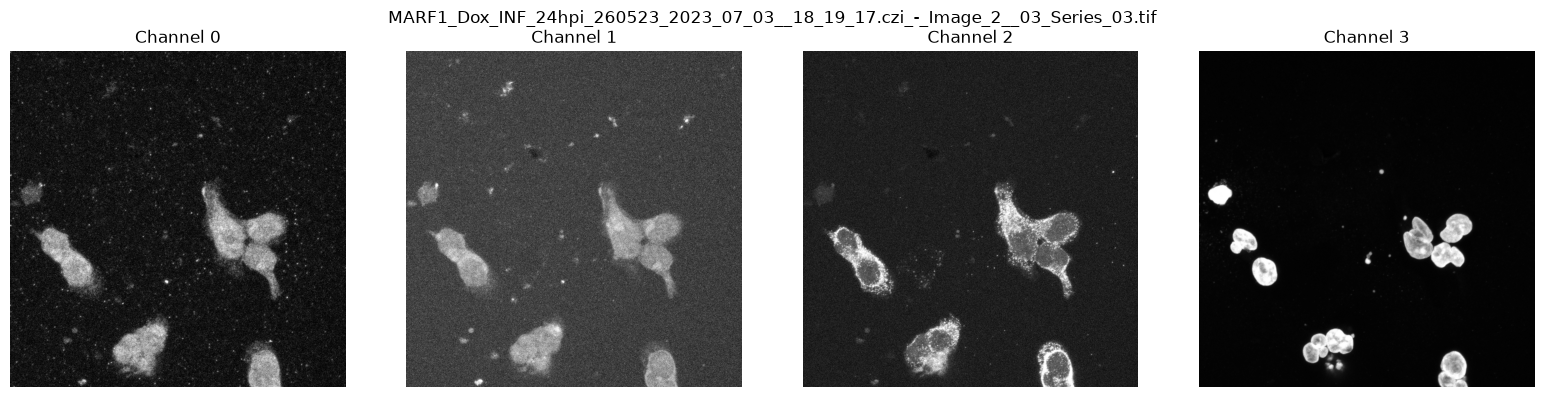

In [4]:
TEST_INDEX = 2  # choose from the file list above
INPUT_AXES = "ZCYX"

test_path = files[TEST_INDEX]
with tifffile.TiffFile(test_path) as tif:
    print(f"{test_path.name}: shape={tif.series[0].shape}, TIFF axes={tif.series[0].axes}")
all_channels = load_projection(test_path, INPUT_AXES)

n_channels = all_channels.shape[-1]
columns = min(4, n_channels)
rows = (n_channels + columns - 1) // columns
fig, axs = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows), squeeze=False)
for i, ax in enumerate(axs.flat):
    if i < n_channels:
        channel = all_channels[..., i]
        lo, hi = np.percentile(channel, [1, 99])
        ax.imshow(channel, cmap="gray", vmin=lo, vmax=max(hi, lo + 1e-6))
        ax.set_title(f"Channel {i}")
    ax.axis("off")
fig.suptitle(test_path.name)
plt.tight_layout()
plt.show()

## Preview · edit and rerun this cell
Choose channels and adjust the settings below, then rerun this cell with **Ctrl+Enter**. The image and model stay loaded. Change one setting at a time and compare outlines on the same image before batching.

- **`CHANNEL_INDICES`**: zero-based channels from the panels above. Select 1–3 useful stains, typically cytoplasm and nuclei; leave out unrelated signals. This is array selection, not the deprecated Cellpose `channels` argument.
- **`channel_axis=-1`**: channels occupy the last axis of the prepared YXC image. Leave this unchanged with this loader.
- **`diameter = None`**: use native scale; no automatic diameter estimation. If cells are very large, try their approximate diameter in pixels (e.g. `325` for the old dataset). A positive diameter rescales relative to 30 pixels; inspect whether smaller cells lose detail after downsampling.
- **`normalize`**: normalize each channel using its 1st–99th intensity percentiles. Keep this on for raw images; use `False` only if you intentionally prepared the input intensities yourself. Panel autocontrast affects display only.
- **`flow_threshold = 0.4`**: reject masks with inconsistent flows. Raise it (e.g. `0.6`) to retain more candidate masks; lower it (e.g. `0.2`) to reject more poorly shaped masks. Higher is more permissive.
- **`cellprob_threshold = 0.0`**: pixel inclusion cutoff. Lower it (e.g. `-1`) to include dimmer regions and often larger/more masks; raise it (e.g. `1`) to suppress background and often shrink/reduce masks. Check both missed cells and false positives.
- **`min_size`**: discard masks smaller than this many pixels. Increase to remove tiny specks; decrease to retain small objects. It is an area cutoff, not a diameter.
- **`batch_size`**: image tiles processed together. Try `2` or `1` if GPU memory is tight; increase cautiously for throughput. This does not set the number of image files.
- **`do_3D=False`**: keep this off because the loader already projects Z. True 3D segmentation needs a different input workflow, not just this switch.

Optional additions to `EVAL_SETTINGS`:

- **`niter=None`** leaves dynamics iterations automatic. Try a larger value such as `2000` for long objects whose masks fail to converge; this takes longer.
- **`bsize=None`** uses each model's default tile size: 256 for SAM, 384 for DINO. DINO permits larger tiles for large/long objects at increased memory cost; SAM requires 256.

The standard Cellpose plot shows input, outlines, masks and flows. Display channels map to R/G/B in selected order. Guidance: [settings](https://cellpose.readthedocs.io/en/latest/settings.html), [API](https://cellpose.readthedocs.io/en/latest/api.html), [models](https://cellpose.readthedocs.io/en/latest/models.html).

/Users/jefflee/Documents/Tools/Image-analysis/Segmentation/Cellpose-SAM-AppleM1/.venv/lib/python3.12/site-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:855.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


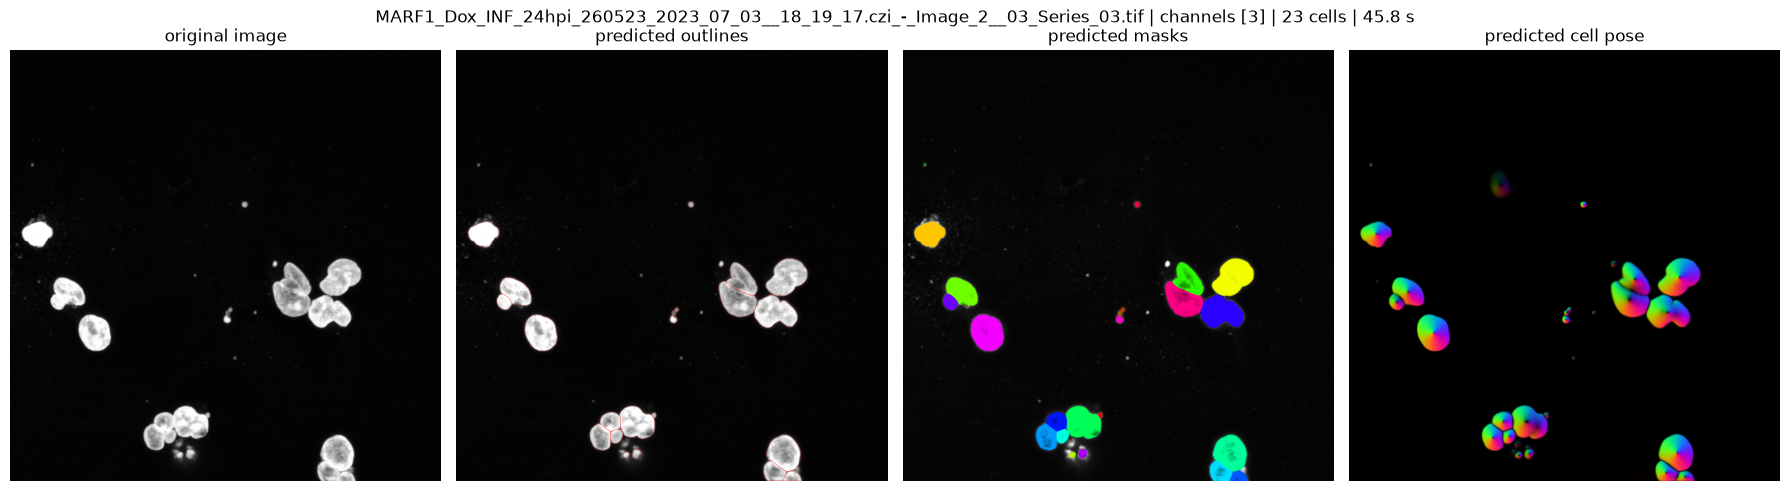

In [5]:
# EDIT THESE SETTINGS, THEN RERUN ONLY THIS CELL (Ctrl+Enter in VS Code).
CHANNEL_INDICES = [3]  # zero-based: up to three [1] matches the old notebook
EVAL_SETTINGS = dict(
    channel_axis = -1, 
    diameter = None, 
    normalize = True,
    flow_threshold = 0.4, 
    cellprob_threshold = 0.0,
    min_size = 15, 
    batch_size = 4, 
    do_3D = False,
)
assert 1 <= len(CHANNEL_INDICES) <= 3, "Select 1–3 channels."
assert all(0 <= c < all_channels.shape[-1] for c in CHANNEL_INDICES), "Invalid channel index."
image = all_channels[..., CHANNEL_INDICES]
started = perf_counter()
masks, flows, _ = model.eval(image, **EVAL_SETTINGS)

# Display-only per-channel autocontrast; model input stays unchanged.
lo, hi = np.percentile(image, [1, 99], axis=(0, 1), keepdims=True)
shown = np.clip((image - lo) / np.maximum(hi - lo, 1e-6), 0, 1)
rgb = np.zeros((*image.shape[:2], 3), dtype=np.float32)
if image.shape[-1] == 1:
    rgb[:] = shown
else:
    rgb[..., :image.shape[-1]] = shown
fig = plt.figure(figsize=(18, 5))
plot.show_segmentation(fig, (rgb * 255).astype(np.uint8), masks, flows[0])
fig.suptitle(f"{test_path.name} | channels {CHANNEL_INDICES} | {int(masks.max())} cells | "
             f"{perf_counter() - started:.1f} s")
plt.tight_layout()
plt.show()

## Batch · run after you are happy with the preview
Uses the current `CHANNEL_INDICES` and `EVAL_SETTINGS` from the preview cell. After changing the folder or axes, rerun image loading and preview before batching. All files must share the same axis layout.

Writes uint32 label TIFFs (background = 0) into `cellpose_sam_results`. Existing outputs are skipped unless `OVERWRITE=True`. Errors stop the loop so you can inspect them; rerunning skips completed files.

In [ ]:
OUTPUT_DIR = INPUT_DIR / "cellpose_sam_results"
OVERWRITE = False
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for path in tqdm(files, desc="Segmenting"):
    output = OUTPUT_DIR / f"{path.name}_label.tif"
    if output.exists() and not OVERWRITE:
        continue
    projected = all_channels if path == test_path else load_projection(path, INPUT_AXES)
    labels, _, _ = model.eval(projected[..., CHANNEL_INDICES], **EVAL_SETTINGS)
    tifffile.imwrite(output, labels.astype(np.uint32),
                     photometric="minisblack", metadata={"axes": "YX"})

print(f"Masks saved to {OUTPUT_DIR}")

References: [Cellpose settings](https://cellpose.readthedocs.io/en/latest/settings.html), [API](https://cellpose.readthedocs.io/en/latest/api.html), [Apple Silicon installation](https://cellpose.readthedocs.io/en/latest/installation.html). Written against Cellpose 4.2.1.1; `eval` returns `(masks, flows, styles)` and the deprecated `channels` / `model_type` arguments are omitted.